In [1]:
import os
import re
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
DATA_DIR = "data"

In [3]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [4]:
def load_imdb_data(data_dir):
    records = []
    for split in ["train", "test"]:
        for label in ["pos", "neg"]:
            folder = os.path.join(data_dir, split, label)
            for fname in os.listdir(folder):
                if fname.endswith(".txt"):
                    with open(os.path.join(folder, fname), encoding="utf-8") as f:
                        text = f.read()
                    records.append({
                                "review": text,
                                "sentiment": 1 if label == "pos" else 0,
                                "split_origin": split
                                   })
    return pd.DataFrame(records)

df = load_imdb_data(f"../{DATA_DIR}")
df.to_csv("imdb_reviews.csv", index=False)

print("Dataset saved to imdb_reviews.csv")
print(f"Total reviews loaded: {len(df)}")

Dataset saved to imdb_reviews.csv
Total reviews loaded: 50000


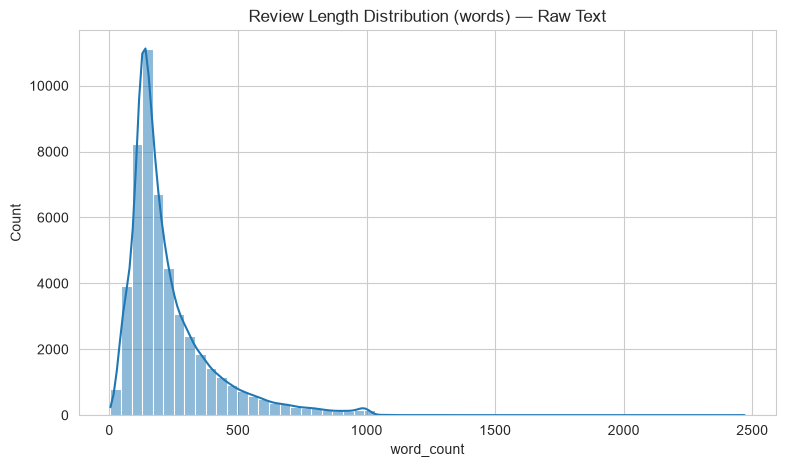

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


In [5]:
df["word_count"] = df["review"].apply(lambda x: len(x.split()))
plt.figure()
sns.histplot(df["word_count"], bins=60, kde=True)
plt.title("Review Length Distribution (words) — Raw Text")
plt.show()
print(df["word_count"].describe())

In [6]:
# This percentile drives our MAX_LEN value for tokenization
pct_95 = int(df["word_count"].quantile(0.95))
print(f"95th percentile review length: {pct_95} words -> informs padding length choice")

95th percentile review length: 590 words -> informs padding length choice


In [7]:
# Cleaning
# (LSTM benefits from raw-ish text + embedding learning, so we keep
#  cleaning minimal: strip HTML/URLs, lowercase, keep punctuation
#  that carries sentiment signal like "!" and "?")
# -----------------------------
def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s!?']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

t0 = time.time()
df["clean_review"] = df["review"].apply(clean_text)
print(f"Cleaning took {time.time() - t0:.2f}s")

Cleaning took 4.18s


In [11]:
# Train/Test Split
X_train = df[df["split_origin"] == "train"]["clean_review"]
y_train = df[df["split_origin"] == "train"]["sentiment"]

X_test = df[df["split_origin"] == "test"]["clean_review"]
y_test = df[df["split_origin"] == "test"]["sentiment"]

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

In [12]:
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 25000 | Test size: 25000


In [14]:
# Tokenization & Padding
VOCAB_SIZE = 20000 # covers 95% - 98% of word occurrences
MAX_LEN = 500  

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
t0 = time.time()
tokenizer.fit_on_texts(X_train_text)
tokenize_fit_time = time.time() - t0

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Tokenizer fit time: {tokenize_fit_time:.2f}s")
print(f"Train padded shape: {X_train_pad.shape}")
print(f"Vocabulary actually used: {min(VOCAB_SIZE, len(tokenizer.word_index))} words")

Tokenizer fit time: 2.69s
Train padded shape: (22500, 500)
Vocabulary actually used: 20000 words


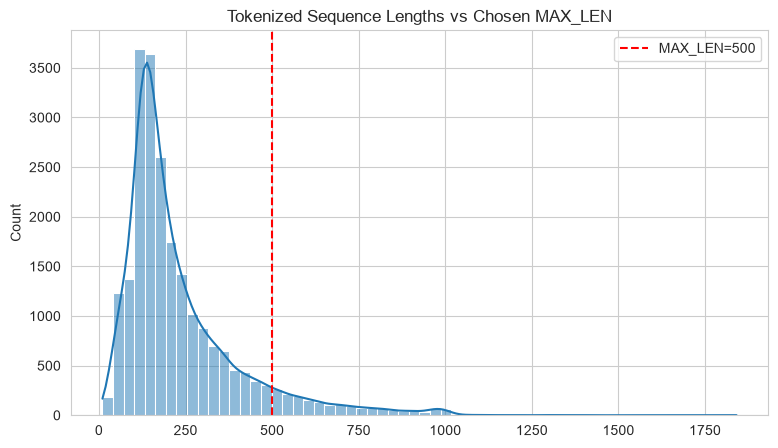

In [15]:
# Visualize sequence length coverage after truncation
seq_lengths = [len(s) for s in X_train_seq]
plt.figure()
sns.histplot(seq_lengths, bins=60, kde=True)
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN={MAX_LEN}")
plt.title("Tokenized Sequence Lengths vs Chosen MAX_LEN")
plt.legend()
plt.show()

In [16]:
coverage = np.mean(np.array(seq_lengths) <= MAX_LEN) * 100
print(f"{coverage:.1f}% of training reviews fit within MAX_LEN={MAX_LEN} without truncation")

92.0% of training reviews fit within MAX_LEN=500 without truncation


In [19]:
# Build LSTM Model
EMBEDDING_DIM = 128

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_shape=(MAX_LEN,)
    ),

    SpatialDropout1D(0.3),

    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 500, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_2                  │ (None, 500, 128)            │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 500, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,704,257 (10.32 MB)

 Trainable params: 2,704,257 (10.32 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Callbacks
early_stop = EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

In [22]:
# Train Model + Timing
BATCH_SIZE = 64
EPOCHS = 10

t0 = time.time()
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
lstm_train_time = time.time() - t0
print(f"\nLSTM training time: {lstm_train_time:.2f}s ({lstm_train_time/60:.2f} min)")

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 311s 886ms/step - accuracy: 0.8078 - auc: 0.8696 - loss: 0.4530 - val_accuracy: 0.8476 - val_auc: 0.9113 - val_loss: 0.3822 - learning_rate: 0.0010
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 344s 978ms/step - accuracy: 0.8696 - auc: 0.9328 - loss: 0.3296 - val_accuracy: 0.7872 - val_auc: 0.8938 - val_loss: 0.5181 - learning_rate: 0.0010
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 287s 816ms/step - accuracy: 0.9137 - auc: 0.9625 - loss: 0.2405 - val_accuracy: 0.8456 - val_auc: 0.9146 - val_loss: 0.3821 - learning_rate: 0.0010
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 259s 737ms/step - accuracy: 0.9198 - auc: 0.9706 - loss: 0.2147 - val_accuracy: 0.8404 - val_auc: 0.9112 - val_loss: 0.4362 - learning_rate: 0.0010
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.9532 - auc: 0.9875 - loss: 0.1314
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
352/352 ━━━━━━━━━━━━━━━━━━━━ 244s 693ms/step - accuracy: 0.9556 - auc:

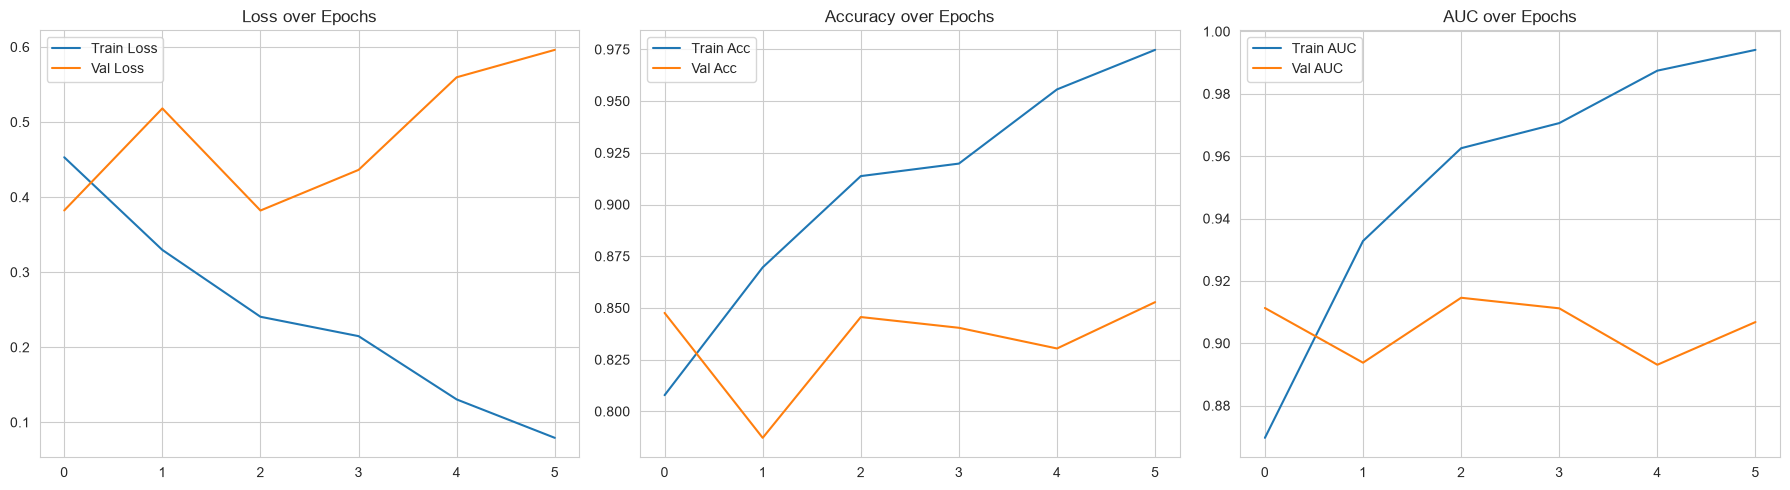

In [23]:
# Training Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy over Epochs")
axes[1].legend()

axes[2].plot(history.history["auc"], label="Train AUC")
axes[2].plot(history.history["val_auc"], label="Val AUC")
axes[2].set_title("AUC over Epochs")
axes[2].legend()
plt.tight_layout()
plt.show()

In [24]:
# Evaluation on Test Set
t0 = time.time()
y_proba = model.predict(X_test_pad, batch_size=BATCH_SIZE).ravel()
inference_time = time.time() - t0
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\n===== LSTM Evaluation =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Inference time on {len(y_test)} test samples: {inference_time:.2f}s")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

391/391 ━━━━━━━━━━━━━━━━━━━━ 67s 169ms/step

===== LSTM Evaluation =====
Accuracy : 0.8319
Precision: 0.8198
Recall   : 0.8507
F1-score : 0.8350
ROC-AUC  : 0.9044
Inference time on 25000 test samples: 66.88s

Classification Report:
               precision    recall  f1-score   support

    Negative       0.84      0.81      0.83     12500
    Positive       0.82      0.85      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



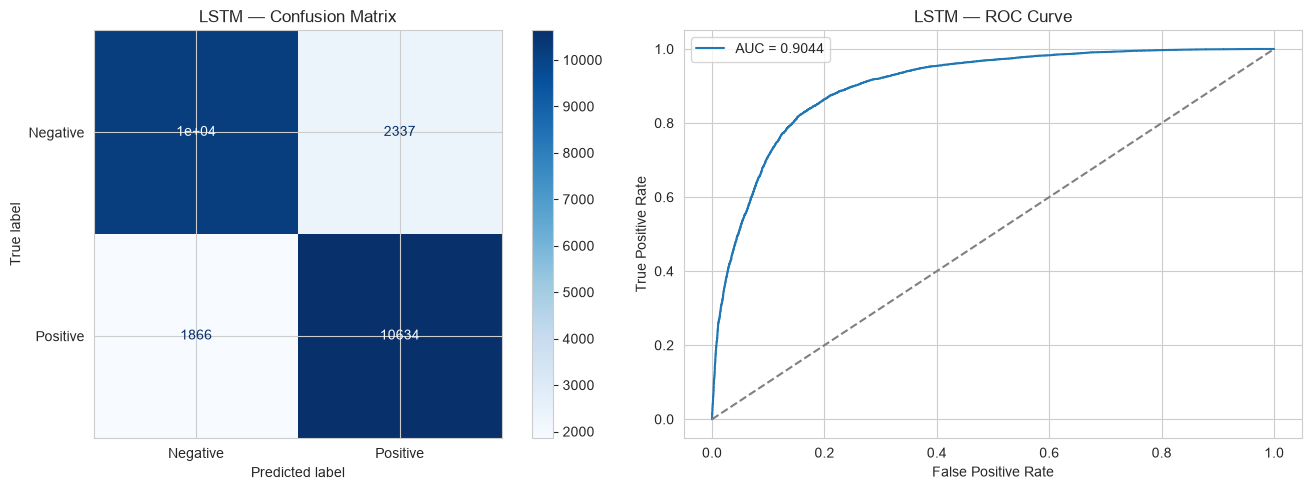

In [25]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("LSTM — Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("LSTM — ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
plt.tight_layout()
plt.show()

In [27]:
# Error Analysis
test_results_df = pd.DataFrame({
    "review": X_test,
    "true_label": y_test,
    "pred_label": y_pred,
    "pred_proba": y_proba
})
misclassified = test_results_df[test_results_df.true_label != test_results_df.pred_label]
print(f"\nMisclassified: {len(misclassified)} / {len(test_results_df)} ({len(misclassified)/len(test_results_df)*100:.2f}%)")
misclassified.sample(min(5, len(misclassified)), random_state=SEED)[["review", "true_label", "pred_label", "pred_proba"]]


Misclassified: 4203 / 25000 (16.81%)


,review,true_label,pred_label,pred_proba
49259,this movie and several other movies from the 1...,0,1,0.870547
42146,i suppose that in 1997 hollywood wasn't quite ...,0,1,0.856935
27359,i don't know if it's fair for me to review thi...,1,0,0.126765
48094,next stop on our journey through the calender ...,0,1,0.949354
38588,ok so this film is well acted it has good dire...,0,1,0.936578


In [28]:
# Final Summary — Timing & Metrics
results_df = pd.DataFrame([{
    "model": "Bidirectional LSTM",
    "accuracy": acc, "precision": prec, "recall": rec,
    "f1": f1, "roc_auc": roc_auc
}])
print("\n================= FINAL RESULTS SUMMARY =================")
print(results_df.to_string(index=False))

print("\n================= TIMING SUMMARY =================")
print(f"Tokenizer fit time   : {tokenize_fit_time:.2f}s")
print(f"Training time        : {lstm_train_time:.2f}s ({lstm_train_time/60:.2f} min)")
print(f"Epochs run           : {len(history.history['loss'])}")
print(f"Inference time (test): {inference_time:.2f}s")
print(f"TOTAL pipeline time  : {tokenize_fit_time + lstm_train_time:.2f}s")

results_df.to_csv("lstm_results.csv", index=False)


================= FINAL RESULTS SUMMARY =================
             model  accuracy  precision  recall       f1  roc_auc
Bidirectional LSTM   0.83188   0.819829 0.85072 0.834989 0.904408

================= TIMING SUMMARY =================
Tokenizer fit time   : 2.69s
Training time        : 1694.82s (28.25 min)
Epochs run           : 6
Inference time (test): 66.88s
TOTAL pipeline time  : 1697.51s
